# Advanced Self-Attention (TensorFlow) - End-to-End Pipeline
**Date**: 2026-05-31  
**Objective**: Benchmark dense, sparse, linear, and grouped-query attention with TensorFlow and shared preprocessing.

## 1) Imports and Setup

In [1]:
from __future__ import annotations

import math
import os
import random
import sys
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

def parse_use_gpu_flag(raw_value: str) -> bool:
    normalized = raw_value.strip().lower()
    return normalized not in {"0", "false", "no", "off"}

def load_runtime_env() -> None:
    env_files = [Path("configs/runtime.env"), Path("configs/runtime.env.example"), Path("../configs/runtime.env"), Path("../configs/runtime.env.example")]
    for env_file in env_files:
        if env_file.exists():
            for line in env_file.read_text(encoding="utf-8").splitlines():
                line = line.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                key, value = line.split("=", 1)
                os.environ.setdefault(key.strip(), value.strip().strip("\"'"))
            break

def register_local_module_path() -> None:
    candidates = [Path("."), Path("self-attention-variants"), Path("../self-attention-variants")]
    for candidate in candidates:
        if (candidate / "shared_text_preprocessing.py").exists():
            resolved = str(candidate.resolve())
            if resolved not in sys.path:
                sys.path.insert(0, resolved)
            return
    raise FileNotFoundError("Could not locate shared_text_preprocessing.py")

load_runtime_env()
register_local_module_path()
USE_GPU = parse_use_gpu_flag(os.getenv("USE_GPU", "1"))
runtime_device = "cuda" if USE_GPU and bool(tf.config.list_physical_devices("GPU")) else "cpu"
print(f"runtime_device={runtime_device}")

from shared_text_preprocessing import PreprocessingConfig, prepare_text_data

runtime_device=cuda


## 2) Configuration and Constants

In [2]:
@dataclass(frozen=True)
class ExperimentConfig:
    num_samples: int = 64
    seq_len: int = 128
    d_model: int = 48
    local_window: int = 8
    temperature_grid_size: int = 31


CFG = ExperimentConfig()
CFG

ExperimentConfig(num_samples=64, seq_len=128, d_model=48, local_window=8, temperature_grid_size=31)

## 3) Data Loading

In [3]:
prep_cfg = PreprocessingConfig(num_samples=CFG.num_samples, seq_len=CFG.seq_len, max_vocab_size=4096, train_ratio=0.8)
data = prepare_text_data(prep_cfg, seed=SEED)
len(data.texts_train), len(data.texts_test), data.y_train.shape, data.y_test.shape

(51, 13, (51,), (13,))

## 4) EDA

In [4]:
train_lengths = np.array([len(t.split()) for t in data.texts_train], dtype=np.int64)
train_class_counts = np.bincount(data.y_train, minlength=2)
test_class_counts = np.bincount(data.y_test, minlength=2)
print("Train class counts:", train_class_counts.tolist())
print("Test class counts:", test_class_counts.tolist())
print("Train token-length mean/std:", float(train_lengths.mean()), float(train_lengths.std()))

Train class counts: [25, 26]
Test class counts: [7, 6]
Train token-length mean/std: 8.0 0.0


## 5) Preprocessing / Feature Engineering

In [5]:
embedding = tf.keras.layers.Embedding(
    input_dim=len(data.vocab),
    output_dim=CFG.d_model,
    embeddings_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.2, seed=SEED),
)
x_train = embedding(tf.convert_to_tensor(data.train_token_ids, dtype=tf.int32))
x_test = embedding(tf.convert_to_tensor(data.test_token_ids, dtype=tf.int32))

def init_projection_weights(d_model: int) -> tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
    w_q = tf.random.normal((d_model, d_model), stddev=0.2, seed=SEED)
    w_k = tf.random.normal((d_model, d_model), stddev=0.2, seed=SEED + 1)
    w_v = tf.random.normal((d_model, d_model), stddev=0.2, seed=SEED + 2)
    return w_q, w_k, w_v

def apply_qkv_projection(x: tf.Tensor, w_q: tf.Tensor, w_k: tf.Tensor, w_v: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
    return tf.linalg.matmul(x, w_q), tf.linalg.matmul(x, w_k), tf.linalg.matmul(x, w_v)

w_q, w_k, w_v = init_projection_weights(CFG.d_model)
q_train, k_train, v_train = apply_qkv_projection(x_train, w_q, w_k, w_v)
q_test, k_test, v_test = apply_qkv_projection(x_test, w_q, w_k, w_v)

## 6) Model Definition (Advanced Variants)

In [6]:
def dense_attention(q: tf.Tensor, k: tf.Tensor, v: tf.Tensor) -> tf.Tensor:
    scores = tf.linalg.matmul(q, k, transpose_b=True) / math.sqrt(float(q.shape[-1]))
    weights = tf.nn.softmax(scores, axis=-1)
    return tf.linalg.matmul(weights, v)

def sparse_with_temperature(q: tf.Tensor, k: tf.Tensor, v: tf.Tensor, window: int, temperature: float) -> tf.Tensor:
    seq_len = tf.shape(q)[1]
    raw = tf.linalg.matmul(q, k, transpose_b=True) / (math.sqrt(float(q.shape[-1])) * temperature)
    idx = tf.range(seq_len)
    distance = tf.abs(tf.expand_dims(idx, 0) - tf.expand_dims(idx, 1))
    local_mask = distance <= window
    local_mask = tf.expand_dims(local_mask, axis=0)
    scores = tf.where(local_mask, raw, tf.fill(tf.shape(raw), tf.constant(-1e9, dtype=raw.dtype)))
    weights = tf.nn.softmax(scores, axis=-1)
    return tf.linalg.matmul(weights, v)

def linear_attention(q: tf.Tensor, k: tf.Tensor, v: tf.Tensor) -> tf.Tensor:
    q_phi = tf.nn.relu(q) + 1e-3
    k_phi = tf.nn.relu(k) + 1e-3
    kv = tf.einsum("bnd,bne->bde", k_phi, v)
    z = 1.0 / (tf.einsum("bnd,bd->bn", q_phi, tf.reduce_sum(k_phi, axis=1)) + 1e-6)
    return tf.einsum("bnd,bde,bn->bne", q_phi, kv, z)

def grouped_query_attention(q: tf.Tensor, k: tf.Tensor, v: tf.Tensor, num_groups: int = 4) -> tf.Tensor:
    batch = q.shape[0]
    seq_len = q.shape[1]
    d_model = q.shape[2]
    if d_model % num_groups != 0:
        raise ValueError(f"d_model ({d_model}) must be divisible by num_groups ({num_groups}).")
    group_dim = d_model // num_groups
    qg = tf.transpose(tf.reshape(q, (batch, seq_len, num_groups, group_dim)), perm=(0, 2, 1, 3))
    k_shared = tf.reduce_mean(tf.reshape(k, (batch, seq_len, num_groups, group_dim)), axis=2)
    v_shared = tf.reduce_mean(tf.reshape(v, (batch, seq_len, num_groups, group_dim)), axis=2)
    outputs = []
    for g in range(num_groups):
        scores = tf.linalg.matmul(qg[:, g], k_shared, transpose_b=True) / math.sqrt(float(group_dim))
        weights = tf.nn.softmax(scores, axis=-1)
        outputs.append(tf.linalg.matmul(weights, v_shared))
    out = tf.stack(outputs, axis=1)
    return tf.reshape(tf.transpose(out, perm=(0, 2, 1, 3)), (batch, seq_len, d_model))

## 7) Training (Sparse Temperature Tuning)

In [7]:
teacher_train = dense_attention(q_train, k_train, v_train)
temp_grid = np.linspace(0.5, 2.0, CFG.temperature_grid_size, dtype=np.float32)
best_temp = float(temp_grid[0])
best_mse = float("inf")

for temp in temp_grid:
    student = sparse_with_temperature(q_train, k_train, v_train, CFG.local_window, float(temp))
    mse = float(tf.reduce_mean((student - teacher_train) ** 2).numpy())
    if mse < best_mse:
        best_mse = mse
        best_temp = float(temp)

print({"best_temperature": best_temp, "train_mse": best_mse})

{'best_temperature': 2.0, 'train_mse': 0.0020699049346148968}


## 8) Evaluation and Metrics

In [8]:
def timed_run(fn, *args):
    start = time.perf_counter()
    out = fn(*args)
    return out, (time.perf_counter() - start) * 1000.0

teacher_test, t_dense = timed_run(dense_attention, q_test, k_test, v_test)
sparse_test, t_sparse = timed_run(sparse_with_temperature, q_test, k_test, v_test, CFG.local_window, best_temp)
linear_test, t_linear = timed_run(linear_attention, q_test, k_test, v_test)
gqa_test, t_gqa = timed_run(grouped_query_attention, q_test, k_test, v_test)

metrics = {
    "dense_ms": float(t_dense),
    "sparse_ms": float(t_sparse),
    "linear_ms": float(t_linear),
    "gqa_ms": float(t_gqa),
    "sparse_mse_vs_dense": float(tf.reduce_mean((sparse_test - teacher_test) ** 2).numpy()),
    "linear_mse_vs_dense": float(tf.reduce_mean((linear_test - teacher_test) ** 2).numpy()),
    "gqa_mse_vs_dense": float(tf.reduce_mean((gqa_test - teacher_test) ** 2).numpy()),
}
metrics

{'dense_ms': 0.6750050001755881,
 'sparse_ms': 1.2023109998153814,
 'linear_ms': 64.0297200002351,
 'gqa_ms': 13.723480999942694,
 'sparse_mse_vs_dense': 0.0021558876615017653,
 'linear_mse_vs_dense': 2.01528691832209e-05,
 'gqa_mse_vs_dense': 0.042705971747636795}

## 9) Results Visualization

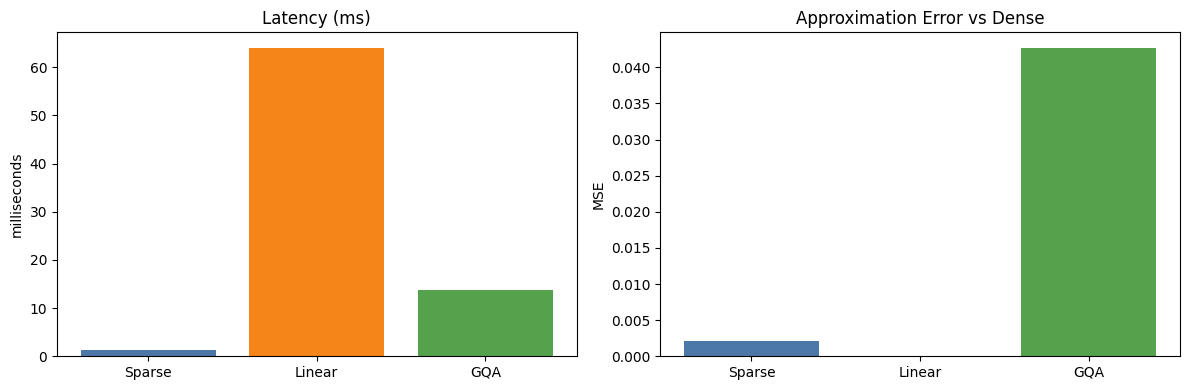

In [9]:
names = ["Sparse", "Linear", "GQA"]
latency = [metrics["sparse_ms"], metrics["linear_ms"], metrics["gqa_ms"]]
mse = [metrics["sparse_mse_vs_dense"], metrics["linear_mse_vs_dense"], metrics["gqa_mse_vs_dense"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(names, latency, color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Latency (ms)")
axes[0].set_ylabel("milliseconds")

axes[1].bar(names, mse, color=["#4C78A8", "#F58518", "#54A24B"])
axes[1].set_title("Approximation Error vs Dense")
axes[1].set_ylabel("MSE")

plt.tight_layout()
plt.show()

## 10) Summary
- Reused shared text tokenization and preprocessing helpers for consistent inputs.
- Benchmarked advanced attention variants in TensorFlow on a shared QKV projection.
- Reported latency and approximation error relative to dense attention.